In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [48]:
df = pd.read_csv("data.csv")
df.head(10)

,Unnamed: 0,day,timestep,IND,AAA,BBB,CCC,DDD,ETF
0,0,1,0,99.13,196.87,307.09,247.92,153.15,226.26
1,1,1,1,99.14,196.66,306.36,247.69,153.18,225.97
2,2,1,2,99.17,196.83,306.89,246.54,153.12,225.84
3,3,1,3,98.99,196.72,307.67,246.80,153.23,226.11
4,4,1,4,98.94,196.36,305.95,246.61,153.30,225.56
5,5,1,5,99.00,196.75,305.17,246.20,153.77,225.49
6,6,1,6,99.06,197.28,305.60,246.43,154.03,225.84
7,7,1,7,99.08,197.23,304.75,246.86,154.16,225.76
8,8,1,8,99.09,197.28,304.09,247.27,153.81,225.62
9,9,1,9,99.20,197.53,303.50,246.42,154.16,225.40


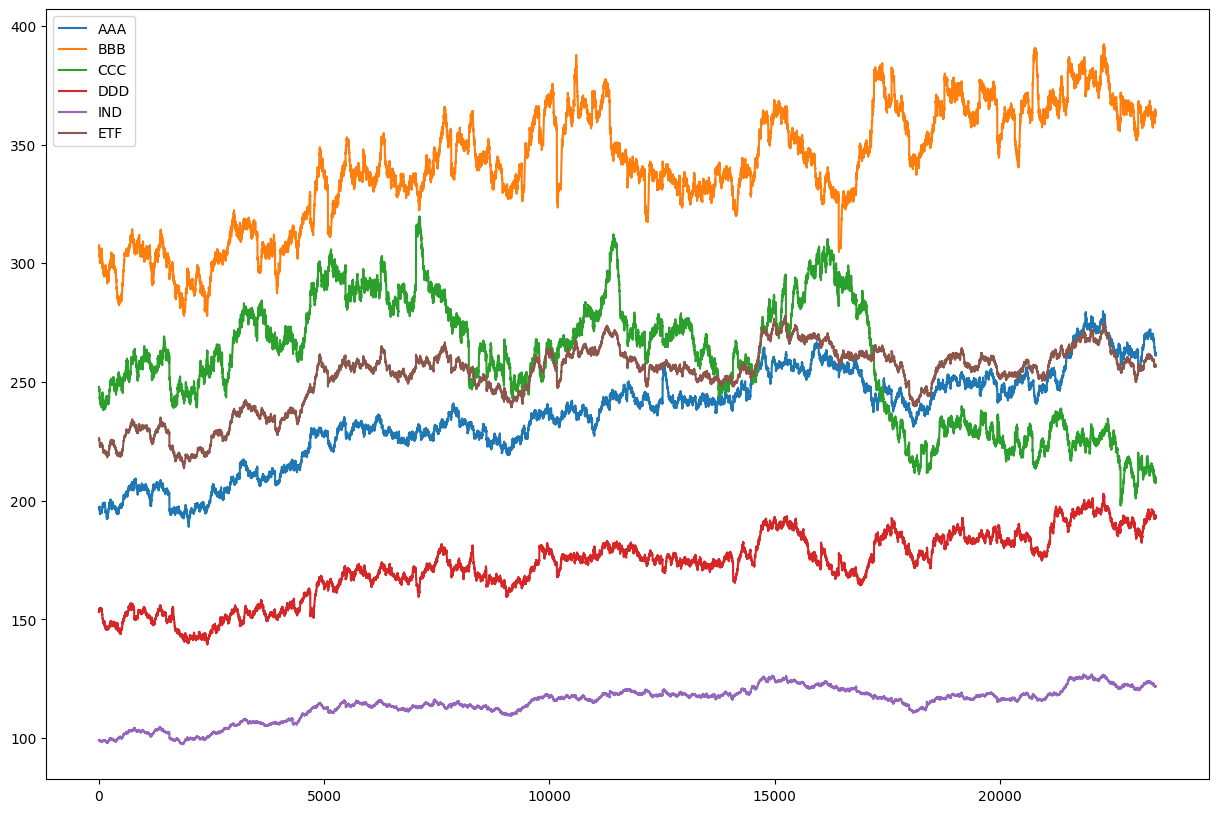

In [78]:
plt.figure(figsize=(15, 10))

plt.plot(df.timestep.index, df.AAA.values, label = "AAA")
plt.plot(df.timestep.index, df.BBB.values, label = "BBB")
plt.plot(df.timestep.index, df.CCC.values, label = "CCC")
# plt.plot(df.timestep.index, ( -df.CCC.values  + df.BBB.values), label = "CCC")
plt.plot(df.timestep.index, df.DDD.values, label = "DDD")
plt.plot(df.timestep.index, df.IND.values, label = "IND")
plt.plot(df.timestep.index, df.ETF.values, label = "ETF")
# plt.plot(df.timestep.index, (df.DDD.values + df.AAA.values + df.BBB.values + df.CCC.values) / 4 , label="Comb")



plt.legend()

In [54]:
import numpy as np
import matplotlib.pyplot as plt
from pykalman import KalmanFilter

In [75]:
observed_position = df.BBB.values

kf = KalmanFilter(initial_state_mean=0, n_dim_obs=1)
kf = kf.em(observed_position, n_iter=1)
smoothed_state, _ = kf.smooth(observed_position)

Text(0, 0.5, 'Position')

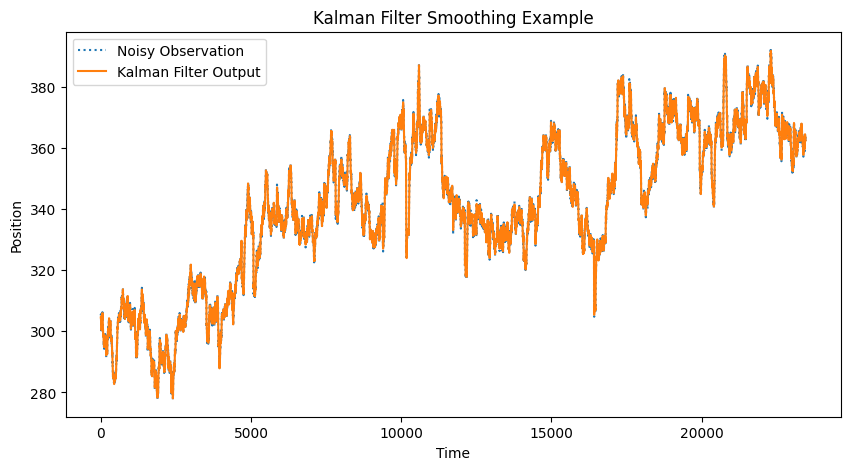

In [76]:
plt.figure(figsize=(10, 5))
plt.plot(observed_position[5:], label='Noisy Observation', linestyle='dotted')
plt.plot(smoothed_state[5:], label='Kalman Filter Output')
plt.legend()
plt.title("Kalman Filter Smoothing Example")
plt.xlabel("Time")
plt.ylabel("Position")


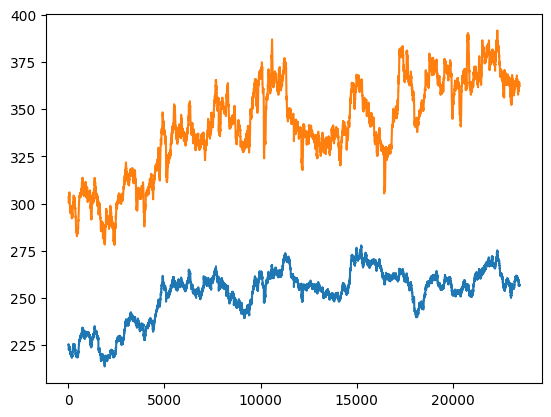

In [77]:
plt.plot(df.timestep.index[10:], df.ETF.values[10:], label = "ETF")
plt.plot(df.timestep.index[10:], smoothed_state[10:], label='Noisy Observation')